# Teste de treinamento de modelo para predição de Resistência utilizando XGBOOST

### Importação de módulos

In [347]:
%%capture
!pip install xgboost optuna

In [348]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, KFold
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from google.colab import drive
import seaborn as sns
import pandas as pd
import numpy as np
import os, optuna

### Montagem do drive

In [349]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [350]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'
filename = 'df_resistencia_XGBoost.pkl'
file_path = os.path.join(dirpath, filename)
os.listdir(dirpath)
df = pd.read_pickle(file_path)
df['target'] = df['Resistencia_Compressao_MPa'].copy()
df.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   Cimento_kg_m3                   599 non-null    float64 
 1   Agregado_Graudo_Total_kg_m3     599 non-null    float64 
 2   Superplastificante_kg_m3        554 non-null    float64 
 3   Relacao_Agua_Cimento            599 non-null    float64 
 4   ln_Idade                        599 non-null    float64 
 5   Tipo_Molde_Cod                  599 non-null    int64   
 6   Metodo_Emp_Cod                  599 non-null    int64   
 7   Classe_Cim_OpA                  599 non-null    int64   
 8   Relacao_Agua_Aglomerante        599 non-null    float64 
 9   Filer_D50_um                    299 non-null    float64 
 10  D_Max                           432 non-null    float64 
 11  vol_ar_aprisionado              554 non-null    float64 
 12  porosidade_volumetrica

In [351]:
def split_target(df, target):
    df.drop(columns=['bins'], inplace=True, errors='ignore')
    y = df[target].copy()
    df.drop(columns=[target], inplace=True)
    return df, y

In [352]:
# 1. Separa 70% para treino e 30% para o resto (mantendo a proporção da coluna 'bins')
df_train, df_temp = train_test_split(
    df,
    test_size=0.3, 
    random_state=42, 
    stratify=df['bins']
)

# 2. Dos 30% restantes, divide em Teste (2/3) e Validação (1/3)
# Isso resulta em 20% do total para Teste e 10% para Validação
df_test, df_val = train_test_split(
    df_temp, 
    test_size=0.3333, 
    random_state=42, 
    stratify=df_temp['bins']
)

df_train.to_pickle(os.path.join(dirpath, 'df_train.pkl'))
df_test.to_pickle(os.path.join(dirpath, 'df_test.pkl'))
df_val.to_pickle(os.path.join(dirpath, 'df_val.pkl'))

X_train, y_train = split_target(df_train, 'target')
X_test, y_test = split_target(df_test, 'target')
X_val, y_val = split_target(df_val, 'target')

In [353]:
print(sum([df_train.isna().sum(), df_test.isna().sum(), df_val.isna().sum()]))

Cimento_kg_m3                       0
Agregado_Graudo_Total_kg_m3         0
Superplastificante_kg_m3           45
Relacao_Agua_Cimento                0
ln_Idade                            0
Tipo_Molde_Cod                      0
Metodo_Emp_Cod                      0
Classe_Cim_OpA                      0
Relacao_Agua_Aglomerante            0
Filer_D50_um                      300
D_Max                             167
vol_ar_aprisionado                 45
porosidade_volumetrica_inicial     45
concentracao_agregados              0
finos_total                         0
volume_pasta                        0
aglomerante_total                   0
agua_solidos                        0
range_granulometrico              399
parametro_feret                    45
idade_ac_feret                     45
dtype: int64


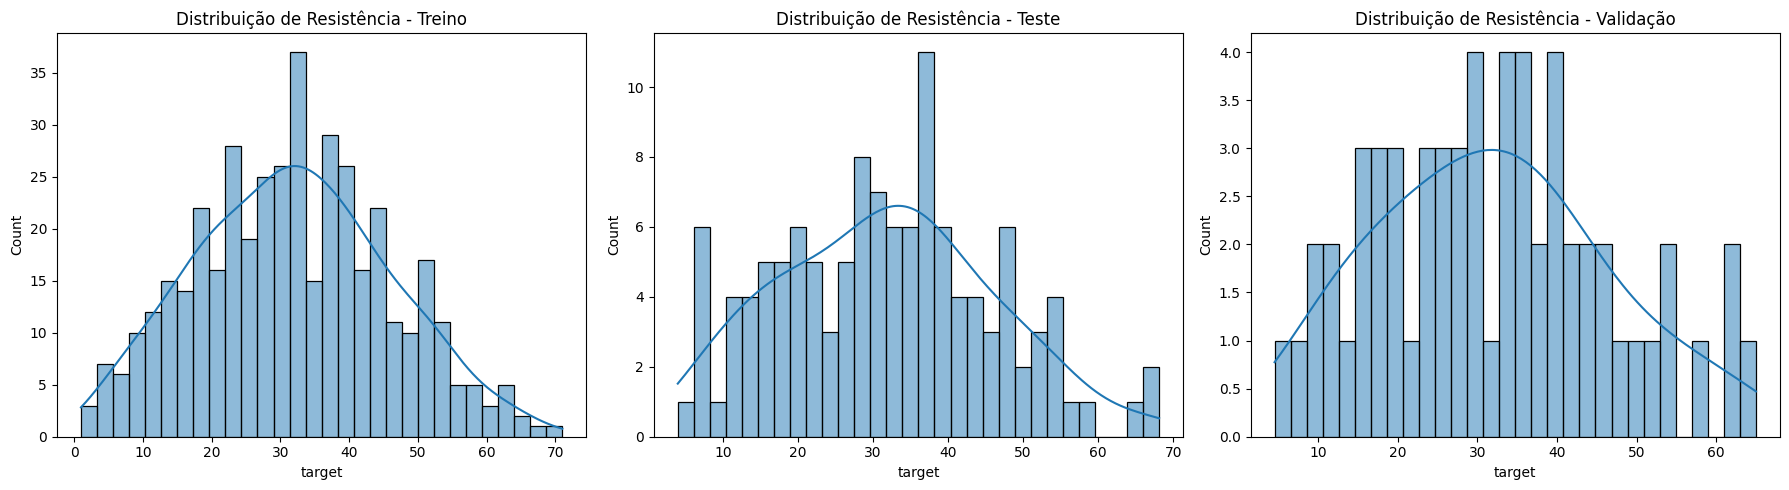

In [354]:
figure, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(y_train, bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribuição de Resistência - Treino')
sns.histplot(y_test, bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribuição de Resistência - Teste')
sns.histplot(y_val, bins=30, kde=True, ax=axes[2])
axes[2].set_title('Distribuição de Resistência - Validação')
plt.tight_layout()
plt.show()

### Validação dos dados de teste, treino e validação

In [355]:
print(f"X_train shape: {X_train.shape}\nX_test shape: {X_test.shape}\nX_val shape: {X_val.shape}\n")
assert X_train.columns.equals(X_test.columns) and X_train.columns.equals(X_val.columns), "As colunas dos DataFrames de treino, teste e validação não são iguais."
print("X_train" + "\n" + "\n".join(f"{c}: {X_train[c].dtype} (NAs: {X_train[c].isna().sum()})" for c in X_train.columns) + "\n")
print("X_test" + "\n" + "\n".join(f"{c}: {X_test[c].dtype} (NAs: {X_test[c].isna().sum()})" for c in X_test.columns) + "\n")
print("X_val" + "\n" + "\n".join(f"{c}: {X_val[c].dtype} (NAs: {X_val[c].isna().sum()})" for c in X_val.columns) + "\n")

X_train shape: (419, 21)
X_test shape: (120, 21)
X_val shape: (60, 21)

X_train
Cimento_kg_m3: float64 (NAs: 0)
Agregado_Graudo_Total_kg_m3: float64 (NAs: 0)
Superplastificante_kg_m3: float64 (NAs: 34)
Relacao_Agua_Cimento: float64 (NAs: 0)
ln_Idade: float64 (NAs: 0)
Tipo_Molde_Cod: int64 (NAs: 0)
Metodo_Emp_Cod: int64 (NAs: 0)
Classe_Cim_OpA: int64 (NAs: 0)
Relacao_Agua_Aglomerante: float64 (NAs: 0)
Filer_D50_um: float64 (NAs: 202)
D_Max: float64 (NAs: 115)
vol_ar_aprisionado: float64 (NAs: 34)
porosidade_volumetrica_inicial: float64 (NAs: 34)
concentracao_agregados: float64 (NAs: 0)
finos_total: float64 (NAs: 0)
volume_pasta: float64 (NAs: 0)
aglomerante_total: float64 (NAs: 0)
agua_solidos: float64 (NAs: 0)
range_granulometrico: float64 (NAs: 273)
parametro_feret: float64 (NAs: 34)
idade_ac_feret: float64 (NAs: 34)

X_test
Cimento_kg_m3: float64 (NAs: 0)
Agregado_Graudo_Total_kg_m3: float64 (NAs: 0)
Superplastificante_kg_m3: float64 (NAs: 8)
Relacao_Agua_Cimento: float64 (NAs: 0)
ln

### Validação dos targets

In [356]:
print(f"y_train shape: {y_train.shape}\ny_test shape: {y_test.shape}\ny_val shape: {y_val.shape}\n")
print("y_train" + "\n" + f"{y_train.name}: {y_train.dtype} (NAs: {y_train.isna().sum()})" + "\n")
print("y_test" + "\n" + f"{y_test.name}: {y_test.dtype} (NAs: {y_test.isna().sum()})" + "\n")
print("y_val" + "\n" + f"{y_val.name}: {y_val.dtype} (NAs: {y_val.isna().sum()})" + "\n")

y_train shape: (419,)
y_test shape: (120,)
y_val shape: (60,)

y_train
target: float64 (NAs: 0)

y_test
target: float64 (NAs: 0)

y_val
target: float64 (NAs: 0)



In [357]:
hyper_params = {
    "booster": "dart", # Mudança estratégica de booster
    "sample_type": "uniform", # Como ele escolhe as árvores para descartar
    "normalize_type": "tree", # Normalização do peso das árvores
    "rate_drop": 0.1, # Descarta 10% das árvores (evita vício)
    "n_estimators": 500, # DART é mais lento, não precisa de tantas árvores
    "learning_rate": 0.05,
    "max_depth": 3,
    "min_child_weight": 3,
    "subsample": 0.5,
    "colsample_bytree": 0.7,
    "reg_lambda": 10,
    "reg_alpha": 1.5,
    "random_state": 42,
    "eval_metric": "rmse"
}



In [358]:
model = XGBRegressor(**hyper_params)

In [359]:
%%time
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# Recupera resultados de avaliação por iteração
evals_result = model.evals_result()

CPU times: user 1min 47s, sys: 667 ms, total: 1min 48s
Wall time: 1min 5s


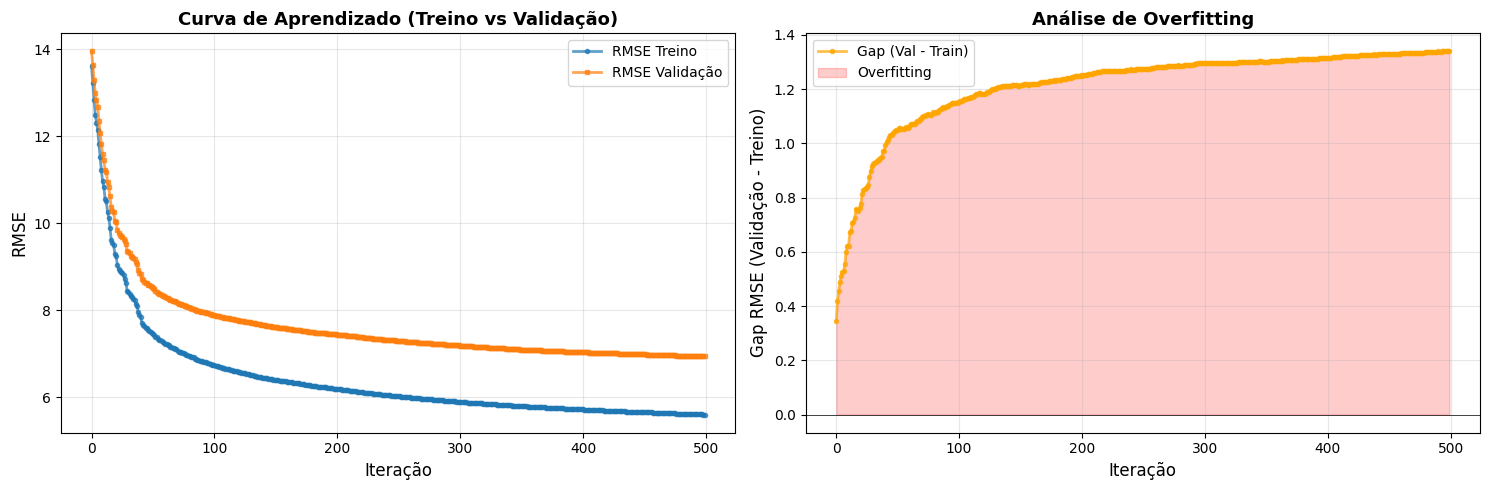

In [360]:
# Plotar curvas de aprendizado (treino vs validação)
train_rmse = evals_result.get('validation_0', {}).get('rmse', [])
val_rmse = evals_result.get('validation_1', {}).get('rmse', [])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Curva de aprendizado completa
ax1 = axes[0]
iterations = range(len(train_rmse))
ax1.plot(iterations, train_rmse, label='RMSE Treino', marker='o', markersize=3, alpha=0.7, linewidth=2)
ax1.plot(iterations, val_rmse, label='RMSE Validação', marker='s', markersize=3, alpha=0.7, linewidth=2)
ax1.set_xlabel('Iteração', fontsize=12)
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_title('Curva de Aprendizado (Treino vs Validação)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Gap de overfitting (Validação - Treino)
ax2 = axes[1]
gap = np.array(val_rmse) - np.array(train_rmse)
ax2.plot(iterations, gap, label='Gap (Val - Train)', marker='o', markersize=3, alpha=0.7, linewidth=2, color='orange')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.fill_between(iterations, 0, gap, where=(gap > 0), alpha=0.2, color='red', label='Overfitting')
ax2.set_xlabel('Iteração', fontsize=12)
ax2.set_ylabel('Gap RMSE (Validação - Treino)', fontsize=12)
ax2.set_title('Análise de Overfitting', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Estatísticas finais
train_final = train_rmse[-1]
val_final = val_rmse[-1]
overfitting_gap = val_final - train_final

print("\n" + "="*60)
print("📊 ANÁLISE DE OVERFITTING E PERFORMANCE")
print("="*60)
print(f"✅ RMSE Treino (final):      {train_final:.6f}")
print(f"⚠️  RMSE Validação (final):   {val_final:.6f}")
print(f"📈 Gap (Val - Train):        {overfitting_gap:.6f}")
print("="*60)


📊 ANÁLISE DE OVERFITTING E PERFORMANCE
✅ RMSE Treino (final):      5.599692
⚠️  RMSE Validação (final):   6.940067
📈 Gap (Val - Train):        1.340375


In [362]:
# Fazer predições no conjunto de teste
y_pred = model.predict(X_test)
debug_df = X_test.copy()

debug_df["pred"] = y_pred
debug_df["ground_truth"] = y_test
debug_df["residual"] = debug_df["ground_truth"] - debug_df["pred"]

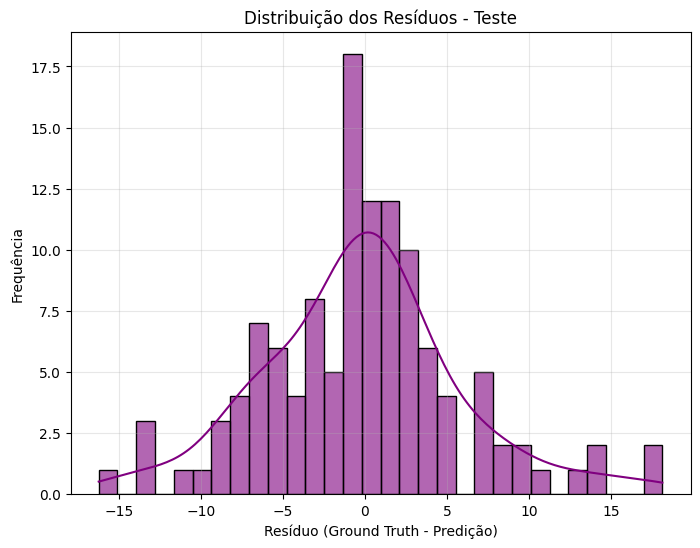

In [363]:
plt.figure(figsize=(8, 6))
sns.histplot(debug_df["residual"], bins=30, kde=True, color='purple', alpha=0.6)
plt.title("Distribuição dos Resíduos - Teste")
plt.xlabel("Resíduo (Ground Truth - Predição)")
plt.ylabel("Frequência")
plt.grid(True, alpha=0.3)
plt.show()

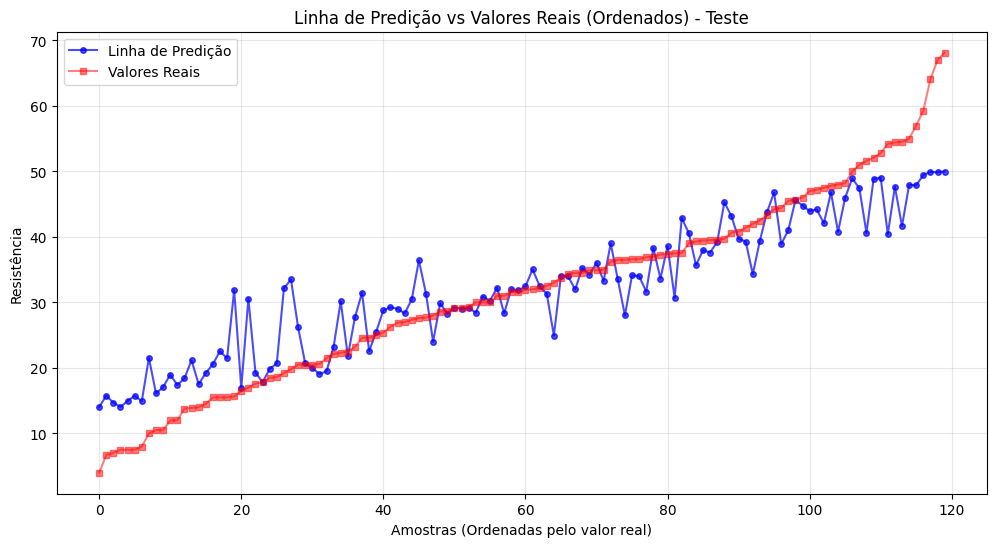

In [364]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = debug_df.sort_values(by="ground_truth").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["pred"], color='blue', label="Linha de Predição", 
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["ground_truth"], color='red', label="Valores Reais", 
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados) - Teste")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Resistência")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [365]:
r2 = r2_score(debug_df["ground_truth"], debug_df["pred"])
rmse = root_mean_squared_error(debug_df["ground_truth"], debug_df["pred"])
mae = mean_absolute_error(debug_df["ground_truth"], debug_df["pred"])
mape = mean_absolute_percentage_error(debug_df["ground_truth"], debug_df["pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 6.0031
mean_absolute_error: 4.3887
mean_absolute_percentage_error: 0.2224
R² Score: 82.2705


In [366]:
y_val_pred = model.predict(X_val)
validation_df = X_val.copy()

validation_df["pred"] = y_val_pred
validation_df["ground_truth"] = y_val
validation_df["residual"] = validation_df["ground_truth"] - validation_df["pred"]

Text(0.5, 1.0, 'Distribuição dos Resíduos - Validação')

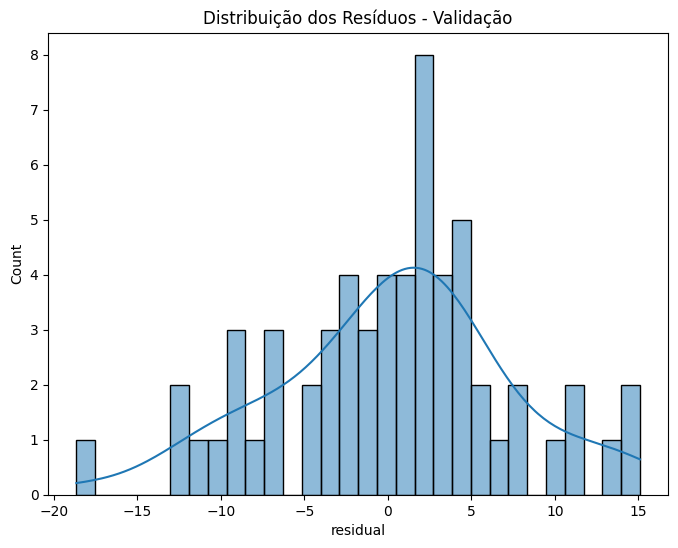

In [367]:
plt.figure(figsize=(8, 6))
sns.histplot(validation_df["residual"], bins=30, kde=True)
plt.title("Distribuição dos Resíduos - Validação")

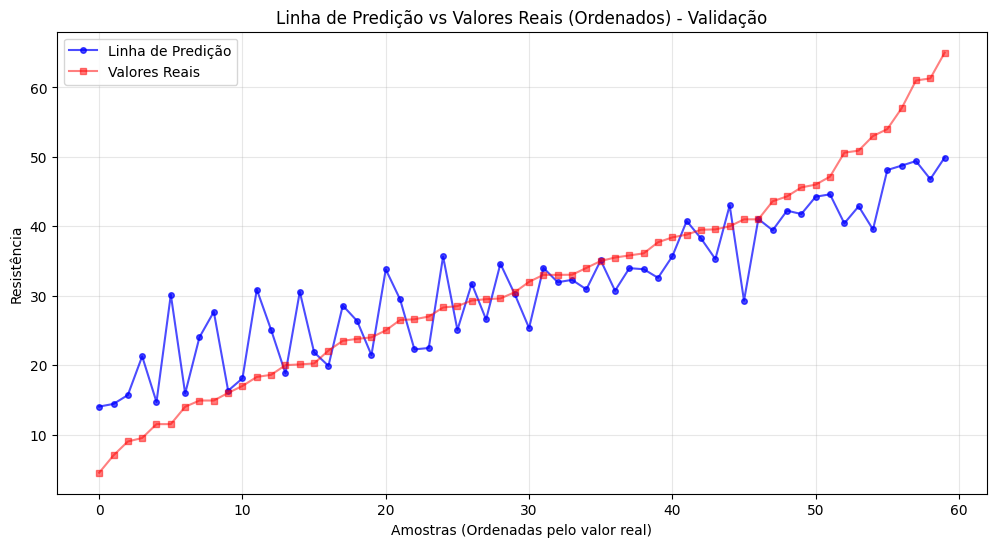

In [368]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
validation_df = validation_df.sort_values(by="ground_truth").reset_index(drop=True)
indices = range(len(validation_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, validation_df["pred"], color='blue', label="Linha de Predição", 
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, validation_df["ground_truth"], color='red', label="Valores Reais", 
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados) - Validação")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Resistência")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [369]:
r2 = r2_score(validation_df["ground_truth"], validation_df["pred"])
rmse = root_mean_squared_error(validation_df["ground_truth"], validation_df["pred"])
mae = mean_absolute_error(validation_df["ground_truth"], validation_df["pred"])
mape = mean_absolute_percentage_error(validation_df["ground_truth"], validation_df["pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 6.9401
mean_absolute_error: 5.3712
mean_absolute_percentage_error: 0.2625
R² Score: 76.6436


In [370]:
model_path = os.path.join(dirpath, "melhor_modelo_resistencia.json")
model.save_model(model_path)
print(f"✅ Modelo salvo em: {model_path}")
print(f"\n📋 Informações do Modelo:")
print(f"  • Número de features: {model.n_features_in_}")
print(f"  • Número de boosting rounds: {model.get_num_boosting_rounds()}")

✅ Modelo salvo em: /content/drive/MyDrive/supervised-learning-studies/projeto/resistencia/melhor_modelo_resistencia.json

📋 Informações do Modelo:
  • Número de features: 21
  • Número de boosting rounds: 500


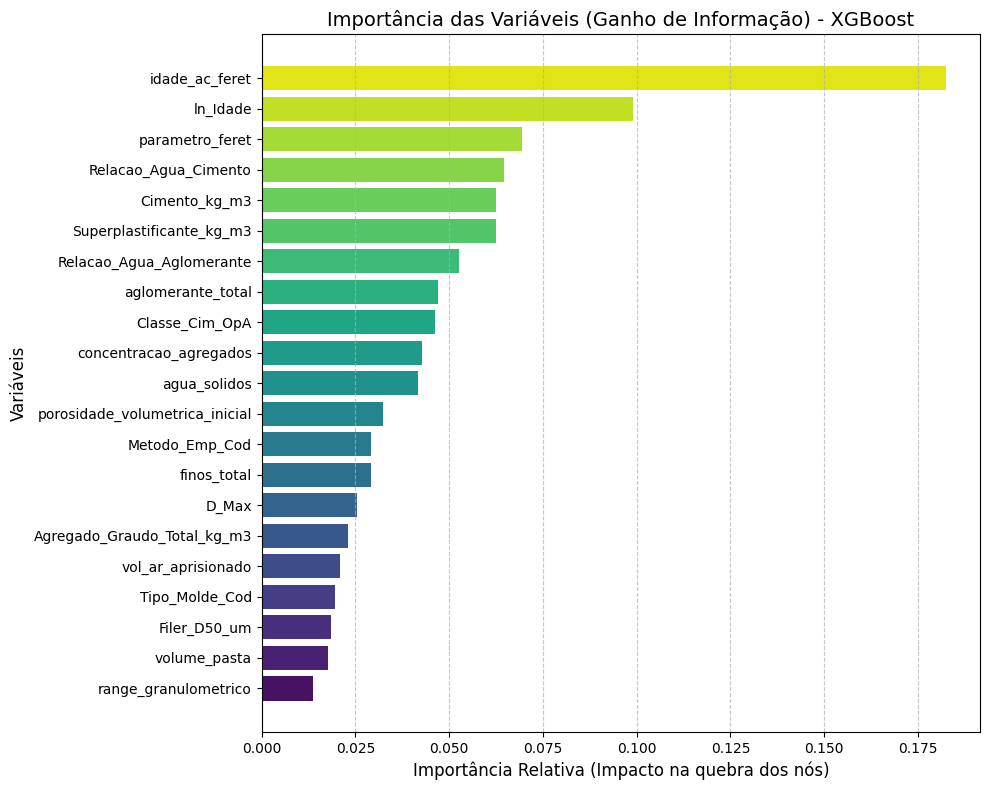

In [371]:
# 1. Extraindo as importâncias direto do modelo XGBoost treinado
# (Assumindo que o seu modelo se chame 'model_xgb')
importancias_xgb = model.feature_importances_

# 2. Criando o DataFrame para organizar os dados
df_importancia_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importancia': importancias_xgb
})

# Ordenando da maior para a menor importância
df_importancia_xgb = df_importancia_xgb.sort_values(by='Importancia', ascending=True)

# 3. Plotando o Gráfico
plt.figure(figsize=(10, 8))

# Criando uma paleta de cores (usando o 'viridis' para diferenciar do gráfico anterior)
cores = sns.color_palette('viridis', n_colors=len(df_importancia_xgb))

# Plotando as barras horizontais
plt.barh(
    y=df_importancia_xgb['Feature'], 
    width=df_importancia_xgb['Importancia'],
    color=cores,
    edgecolor='none'
)

plt.title('Importância das Variáveis (Ganho de Informação) - XGBoost', fontsize=14)
plt.xlabel('Importância Relativa (Impacto na quebra dos nós)', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()